In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.preprocessing import OrdinalEncoder
# from sklearn.impute import KNNImputer

import joblib

In [4]:
df = pd.read_csv('../data/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.shape

(768, 9)

In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# (df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum()
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

* here the '0' means the nan
* because the glucose blood pressure skinthickness insulin bmi cannot be zero in human.
* '0' is just denoting the null values here

In [8]:
# class InsulinPreprocessor(BaseEstimator, TransformerMixin):
#     def fit(self, X, y=None):
#         # Nothing to train here, just returning self
#         return self
        
#     def transform(self, X):
#         X_copy = X.copy() # Good practice to avoid modifying original data
        
#         # 1. Convert physiological 0s to NaN (just in case the frontend sends 0 instead of blank)
#         X_copy['Insulin'] = X_copy['Insulin'].replace(0, np.nan)
        
#         # 2. Create the Missing Indicator column
#         X_copy['Insulin_Missing'] = X_copy['Insulin'].isna().astype(int)
        
#         # 3. Fill the actual missing values with -999
#         X_copy['Insulin'] = X_copy['Insulin'].fillna(-999)
        
#         return X_copy

In [9]:
X = df.drop('Outcome', axis = 1)
y = df['Outcome']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=48)

In [11]:
# 1. Define the specific columns for each "lane"
median_cols = ['Glucose', 'BloodPressure', 'BMI']
insulin_col = ['Insulin']
drop_cols = ['SkinThickness']

# 2. Define the exact transformations
# Lane 1: Replace 0s with the median
median_imputer = SimpleImputer(missing_values=0, strategy='median')

# Lane 2: The Insulin Super-Imputer
# This automatically replaces 0 with -999 AND creates a new boolean column (1 if missing, 0 if not)
insulin_imputer = SimpleImputer(
    missing_values=0, 
    strategy='constant', 
    fill_value=-999, 
    add_indicator=True 
)

# 3. Build the ColumnTransformer (The Traffic Director)
preprocessor = ColumnTransformer(
    transformers=[
        ('median_transforms', median_imputer, median_cols),
        ('insulin_transform', insulin_imputer, insulin_col),
        ('drop_skin_thickness', 'drop', drop_cols) # Literally just use the word 'drop'
    ],remainder='passthrough')

In [12]:
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',DecisionTreeClassifier())
])

In [13]:
final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('median_transforms', ...), ('insulin_transform', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [14]:
predictions = final_pipeline.predict(X_test)

In [15]:
accuracy_score(y_test, predictions)

0.7207792207792207

In [16]:
# 1. Define the grid of parameters you want to test
# Notice the 'classifier__' prefix attached to every parameter
param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 4, 5, 7, 10], # Limits how deep the tree grows
    'classifier__min_samples_split': [2, 5, 10], # Minimum samples required to split an internal node
    'classifier__min_samples_leaf': [1, 5, 10, 20] # Minimum samples required to be at a leaf node
}

In [17]:
# 2. Set up the GridSearchCV
# cv=5 means 5-fold cross-validation
# n_jobs=-1 uses all your computer's CPU cores to run it faster
grid_search = GridSearchCV(
    estimator=final_pipeline, # Pass your ENTIRE pipeline here
    param_grid=param_grid,
    cv=5,
    scoring='accuracy', # We can change this to 'recall' or 'f1' if you prefer
    n_jobs=-1,
    verbose=1 # Prints out progress so you aren't staring at a blank screen
)

In [18]:
# 3. Fit the Grid Search to your training data
# This will test all combinations (2 * 5 * 3 * 4 = 120 different models!)
print("Starting hyperparameter tuning...")
grid_search.fit(X_train, y_train)

# 4. Extract the results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# 5. Get your final, perfectly tuned pipeline
best_pipeline = grid_search.best_estimator_

Starting hyperparameter tuning...
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 4, 'classifier__min_samples_leaf': 20, 'classifier__min_samples_split': 2}
Best Cross-Validation Score: 0.7557


In [19]:
predictions_after_tuning = best_pipeline.predict(X_test)

In [20]:
accuracy_score(predictions_after_tuning, y_test)

0.7532467532467533

In [21]:
from pathlib import Path

BASE_DIR = Path().resolve().parent
model_path = BASE_DIR / "models" / "diabetes_production_model.pkl"

joblib.dump(best_pipeline, model_path)

print("Model successfully saved and ready for deployment!")

Model successfully saved and ready for deployment!


In [213]:

# ---------------------------------------------------------------------------------------------------------------------------------- #

In [37]:
df.sample()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
220,0,177,60,29,478,34.6,1.072,21,1


In [39]:
# need top 10 max insulin values 
df['Insulin'].nlargest(10)

13     846
228    744
247    680
584    600
409    579
286    545
8      543
655    540
753    510
111    495
Name: Insulin, dtype: int64

In [230]:
import sklearn
print(sklearn.__version__)

1.6.1


In [98]:
(df == 0).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [27]:
df['Pregnancies'].unique()

array([ 6,  1,  8,  0,  5,  3, 10,  2,  4,  7,  9, 11, 13, 15, 17, 12, 14],
      dtype=int64)

In [134]:
df['Pregnancies'].value_counts()

Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
15      1
17      1
Name: count, dtype: int64

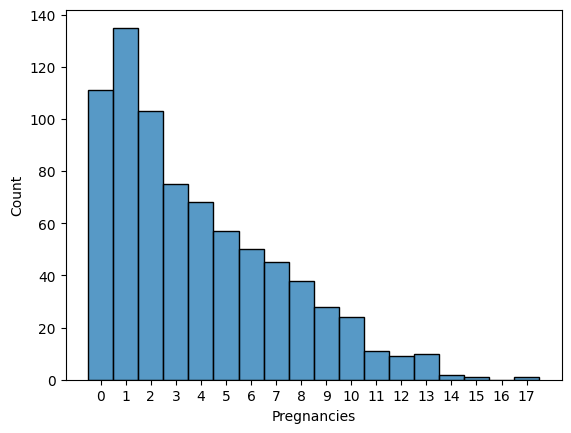

In [136]:
sns.histplot(data = df, x ='Pregnancies',discrete=True)
# 2. Set ticks to show every integer from 0 to 17
plt.xticks(range(18)) 
plt.show()

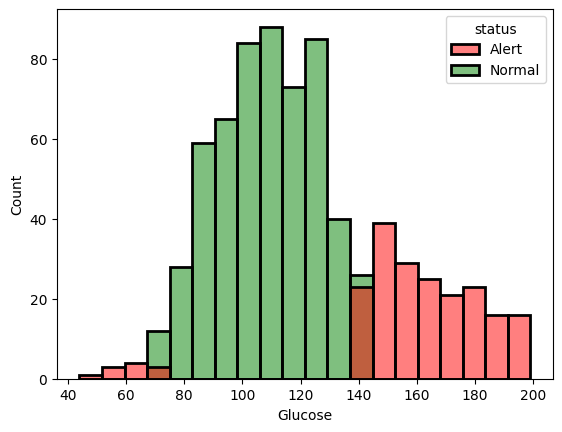

In [138]:
# 1. Create a conditional column
df['status'] = 'Normal'
df.loc[(df['Glucose'] < 70) | (df['Glucose'] > 140), 'status'] = 'Alert'

# 2. Plot using hue and a specific palette
sns.histplot(data=df, x='Glucose', hue='status', 
             palette={'Alert': 'red', 'Normal': 'green'}, 
             bins=20, edgecolor = 'black', linewidth=2)
plt.show()

In [140]:
df.drop('status',axis = 1, inplace = True)

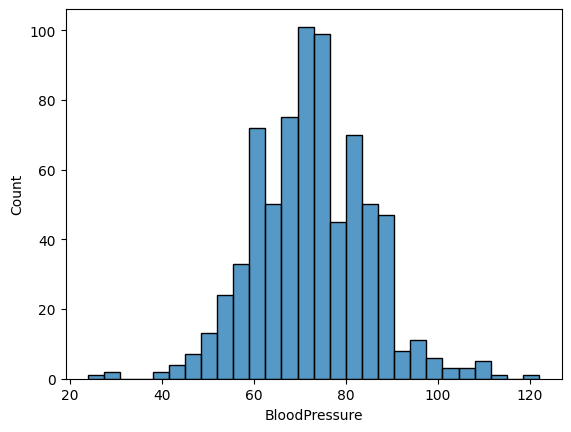

In [144]:
sns.histplot(data =df, x='BloodPressure')
plt.show()

In [70]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
158,2,88,74,19,53,29.0,0.229,22
573,2,98,60,17,120,34.7,0.198,22
429,1,95,82,25,180,35.0,0.233,43
740,11,120,80,37,150,42.3,0.785,48
589,0,73,0,0,0,21.1,0.342,25
...,...,...,...,...,...,...,...,...
407,0,101,62,0,0,21.9,0.336,25
601,6,96,0,0,0,23.7,0.190,28
243,6,119,50,22,176,27.1,1.318,33
321,3,112,74,30,0,31.6,0.197,25


In [72]:
clf = DecisionTreeClassifier()

In [74]:
clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [76]:
y_pred = clf.predict(X_test)

In [78]:
accuracy_score(y_test, y_pred)

0.6948051948051948

In [89]:
clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

## Hyper paramter tuning

In [91]:
param_dist = {
    'criterion': ['gini','entropy'],
    'max_depth' : [1, 2, 3, 4, 5, 6, 7, None]
}

In [97]:
grid = GridSearchCV(clf, param_grid = param_dist, cv = 10, n_jobs = -1)

In [99]:
grid.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, None]})

In [101]:
grid.best_params_

{'criterion': 'gini', 'max_depth': 4}

In [103]:
grid.best_score_

0.7459280803807509

In [ ]:
# grid.